In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
# Seed zapewnia identyczne dane u każdego studenta
np.random.seed(42)
n = 200
dzialy = np.random.choice(['IT', 'Sprzedaz', 'HR', 'Marketing', 'Finanse'], n,
 p=[0.30, 0.25, 0.15, 0.20, 0.10])
staz = np.random.gamma(shape=3, scale=2, size=n).clip(0.5, 20).round(1)
baza = {'IT': 9000, 'Sprzedaz': 7000, 'HR': 6500, 'Marketing': 7500, 'Finanse':
8500}
wynagrodzenie = np.array([
 baza[d] + staz[i] * 300 + np.random.normal(0, 1200)
 for i, d in enumerate(dzialy)
]).clip(4000, 25000).round(-2)
# 5 celowo wstawionych outlierów (błędy danych / kontrakty specjalne)
wynagrodzenie[np.random.choice(n, 5, replace=False)] = np.random.choice(
 [2000, 2500, 35000, 40000, 38000], 5, replace=False
)
df = pd.DataFrame({
 'dzial': dzialy,
 'staz_lat': staz,
 'wynagrodzenie': wynagrodzenie,
 'wiek': (25 + staz + np.random.normal(0, 3, n)).clip(22,
65).round().astype(int),
 'ocena_roczna': np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.40,
0.35, 0.10])
})
print(f"Dataset HR: {df.shape[0]} pracowników, {df.shape[1]} kolumn")
print(df.head())
print("\nTypy kolumn:")
print(df.dtypes)

## Ćwiczenie 1: Statystyki opisowe na danych biznesowych 
Kontekst biznesowy: Jesteś analitykiem w dziale HR firmy technologicznej. Dyrektor personalny pyta: "Jak
wyglądają nasze wynagrodzenia? Czy są zróżnicowane? Który dział płaci najlepiej?" Twoim zadaniem jest
przygotowanie raportu statystycznego.
### 1a. Miary tendencji centralnej
Oblicz i wyświetl średnią, medianę i dominantę kolumny wynagrodzenie. Wynik sformatuj jako PLN.

In [14]:
placa=df['wynagrodzenie']
srednia=placa.mean()
mediana=placa.median()
dominanta=placa.mode()[0]
print("=== MIARY TENDENCJI CENTRALNEJ ===")
print(f"Średnia: {srednia:>10,.0f} PLN")
print(f"Mediana: {mediana:>10,.0f} PLN")
print(f"Dominanta: {dominanta:>10,.0f} PLN")


=== MIARY TENDENCJI CENTRALNEJ ===
Średnia:      9,940 PLN
Mediana:      9,450 PLN
Dominanta:      9,500 PLN


### 1b. Miary rozproszenia
Oblicz odchylenie standardowe, IQR i rozstęp wynagrodzeń

In [ ]:
odch_std=placa.std()
q1=placa.quantile(0.25)
q3=placa.quantile(0.75)
iqr=q3-q1
rozstep=placa.max()-placa.min()
print("=== MIARY ROZPROSZENIA ===")
print(f"Odchylenie std: {odch_std:>10,.0f} PLN")
print(f"Q1 (P25): {q1:>10,.0f} PLN")
print(f"Q3 (P75): {q3:>10,.0f} PLN")
print(f"IQR: {iqr:>10,.0f} PLN")
print(f"Rozstęp: {rozstep:>10,.0f} PLN")
# rzostep jest duzy poniewaz szefowie zarabiaja wartosci odstajace i w porownaniu do zwyklych pracowników jest ogromna roznica pracy jednakze takich wynikow nie ma duzo


=== MIARY ROZPROSZENIA ===
Odchylenie std:      3,980 PLN
Q1 (P25):      8,200 PLN
Q3 (P75):     10,700 PLN
IQR:      2,500 PLN
Rozstęp:     38,000 PLN


### 1c. Statystyki per dział
Oblicz średnią, medianę i odchylenie standardowe per dział, posortowane malejąco po medianie.


In [18]:
dzialy_status=df.groupby('dzial',observed=True)['wynagrodzenie'].agg(['mean','median','std']).round(0).sort_values('median',ascending=False)
dzialy_status.columns=['Średnia','Mediana','Std']
print("=== WYNAGRODZENIA PER DZIAŁ ===")
print(dzialy_status)

=== WYNAGRODZENIA PER DZIAŁ ===
           Średnia  Mediana     Std
dzial                              
IT         11108.0  10600.0  4145.0
Finanse    10621.0  10400.0  1741.0
Marketing   9476.0   9100.0  4386.0
HR          8354.0   8400.0  1622.0
Sprzedaz    9282.0   8400.0  4428.0


### 1d. Wizualizacja — histogram z miarami centralnymi

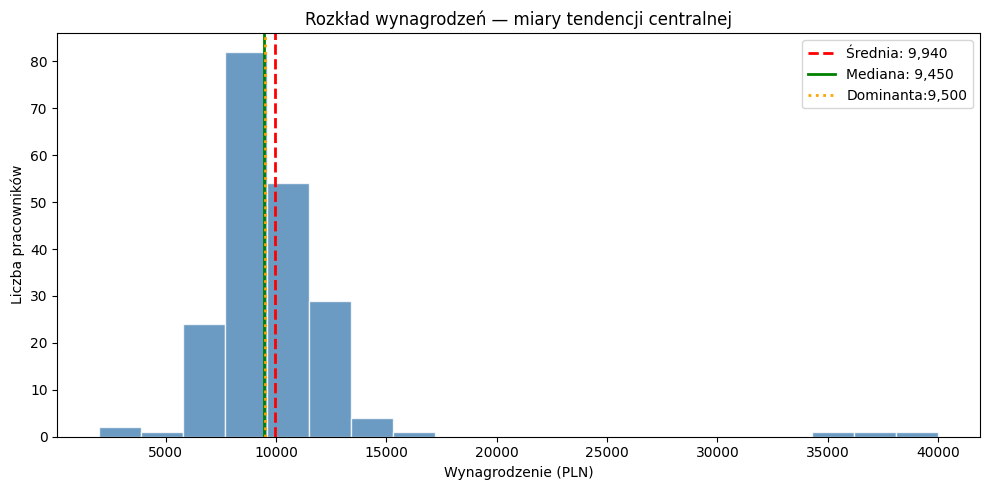

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(placa,bins=20,color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(srednia, color='red', linestyle='--', lw=2, label=f'Średnia: {srednia:,.0f}')
ax.axvline(mediana, color='green', linestyle='-', lw=2, label=f'Mediana: {mediana:,.0f}')
ax.axvline(dominanta, color='orange', linestyle=':', lw=2, label=f'Dominanta:{dominanta:,.0f}')

ax.set_title('Rozkład wynagrodzeń — miary tendencji centralnej')
ax.set_xlabel('Wynagrodzenie (PLN)')
ax.set_ylabel('Liczba pracowników')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

## Ćwiczenie 2: Analiza korelacji 
Kontekst biznesowy: Dyrektor finansowy pyta: "Co decyduje o wysokości wynagrodzenia — staż pracy, wiek,
a może ocena roczna? A jak wygląda zależność między wydatkami na marketing a przychodami?" Twoja
analiza pomoże podjąć decyzję o polityce wynagrodzeń i budżecie marketingowym.
### 2a. Korelacja Pearsona: staż vs wynagrodzenie

In [29]:
r, p_value=stats.pearsonr(df['staz_lat'], df['wynagrodzenie'])
print(f"Korelacja Pearsona (staż–wynagrodzenie):")
print(f" r = {r:.4f}")
print(f" p = {p_value:.4f}")
print(f" Interpretacja: {'istotna' if p_value < 0.05 else 'nieistotna'} statystycznie")

Korelacja Pearsona (staż–wynagrodzenie):
 r = 0.3198
 p = 0.0000
 Interpretacja: istotna statystycznie


### 2b. Korelacja Spearmana — porównanie


In [30]:
rho, p_rho = stats.spearmanr(df['staz_lat'], df['wynagrodzenie'])
print(f"Korelacja Spearmana (staż–wynagrodzenie):")
print(f" rho = {rho:.4f}")
print(f" p = {p_rho:.4f}")
print(f"\nPorównanie: Pearson r={r:.3f} vs Spearman rho={rho:.3f}")
print(f"Różnica: {abs(rho - r):.3f} — {'duże' if abs(rho-r) > 0.1 else 'małe'}rozbieżności")



Korelacja Spearmana (staż–wynagrodzenie):
 rho = 0.5219
 p = 0.0000

Porównanie: Pearson r=0.320 vs Spearman rho=0.522
Różnica: 0.202 — dużerozbieżności


### 2c. Macierz korelacji — wszystkie zmienne

Macierz korelacji Pearsona:
               staz_lat  wynagrodzenie   wiek  ocena_roczna
staz_lat          1.000          0.320  0.756        -0.057
wynagrodzenie     0.320          1.000  0.219        -0.054
wiek              0.756          0.219  1.000        -0.081
ocena_roczna     -0.057         -0.054 -0.081         1.000


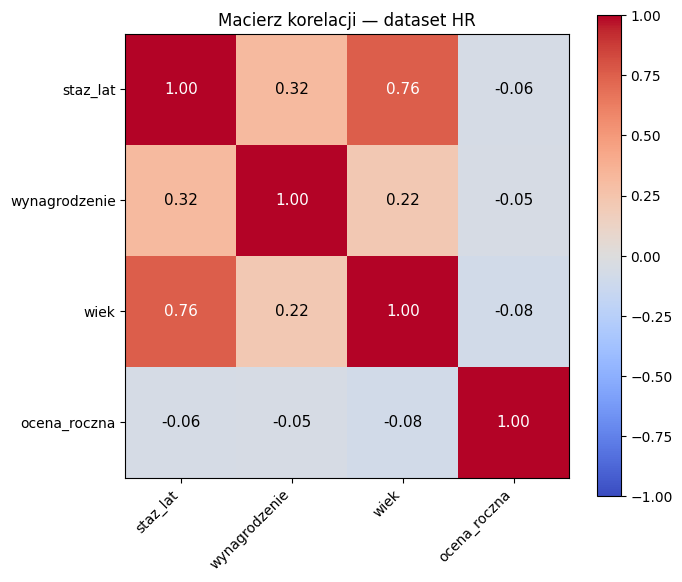

In [36]:
corr=df[['staz_lat','wynagrodzenie','wiek','ocena_roczna']].corr()
print("Macierz korelacji Pearsona:")
print(corr.round(3))
fig, ax = plt.subplots(figsize=(7, 6))
# Rysuj heatmapę ręcznie (bez seaborn)
im=ax.imshow(corr.values,cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range (len(corr)):
    for j in range (len(corr.columns)):
        ax.text(j,i,f'{corr.values[i,j]:.2f}',ha='center',va='center',fontsize=11,color='black' if abs(corr.values[i,j]) < 0.7 else 'white')
ax.set_title('Macierz korelacji — dataset HR')
plt.tight_layout()
plt.show()
plt.close()


### 2d. Korelacja: marketing spend vs revenue
Poniższe dane symulują miesięczne wydatki marketingowe i przychody firmy. Zbadaj zależność.


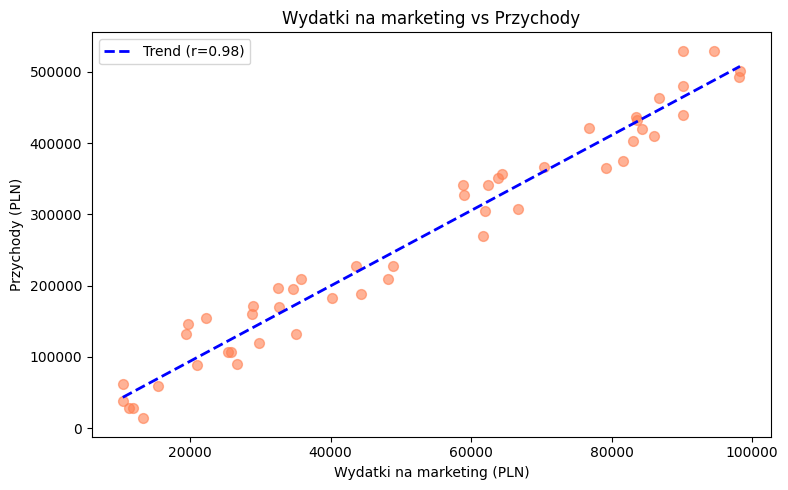

Marketing spend vs Revenue: r = 0.9806, p = 1.22e-35


In [2]:
np.random.seed(100)
n_mkt = 50
marketing_spend = np.random.uniform(10000, 100000, n_mkt)
revenue = marketing_spend * 5.2 + np.random.normal(0, 30000, n_mkt)
revenue = revenue.clip(0)
r_mkt,p_mkt=stats.pearsonr(marketing_spend,revenue)
fig,ax=plt.subplots(figsize=(8,5))
ax.scatter(marketing_spend,revenue,alpha=0.6,color='coral', s=50)
z=np.polyfit(marketing_spend,revenue,1)
p_fit=np.poly1d(z)
x_line=np.linspace(marketing_spend.min(),marketing_spend.max(),100)
ax.plot(x_line, p_fit(x_line), 'b--', lw=2, label=f'Trend (r={r_mkt:.2f})')
ax.set_title('Wydatki na marketing vs Przychody')
ax.set_xlabel('Wydatki na marketing (PLN)')
ax.set_ylabel('Przychody (PLN)')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()
print(f"Marketing spend vs Revenue: r = {r_mkt:.4f}, p = {p_mkt:.2e}")



## Ćwiczenie 3: Pełna analiza statystyczna datasetu HR 
mniejszym wsparciem
Kontekst biznesowy: Przygotowujesz kompleksowy raport HR dla zarządu. Raport musi zawierać: opis
rozkładu wynagrodzeń (skośność, kurtoza), analizę percentylową, porównanie działów i wnioski biznesowe.
Całość w jednym notebooku, czytelnie sformatowana.
Zadania do wykonania samodzielnie:
### 3a. scipy.stats.describe — szybki przegląd rozkładu
Użyj stats.describe() na kolumnie wynagrodzenie. Wyświetl wszystkie 6 miar i zinterpretuj skośność i
kurtozę słownie.

In [ ]:
from scipy import stats

# Obliczenie statystyk
opis = stats.describe(df['wynagrodzenie'])

# Wyświetlenie wyników
print(f"N obserwacji: {opis.nobs}")
print(f"Min: {opis.minmax[0]}, Max: {opis.minmax[1]}")
print(f"Średnia: {opis.mean:.2f}")
print(f"Wariancja: {opis.variance:.2f}")
print(f"Skośność: {opis.skewness:.2f}")
print(f"Kurtoza: {opis.kurtosis:.2f}")

## 3b. Analiza percentylowa


In [ ]:
percentyle = df['wynagrodzenie'].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
print(percentyle)

## 3c. Analiza per dział — pełna tabela

In [ ]:
dzialy_stats = df.groupby('dzial', observed=True)['wynagrodzenie'].agg(
    ['mean', 'median', 'std', 'min', 'max', lambda x: x.quantile(0.75) - x.quantile(0.25)]
)
dzialy_stats.columns = ['Średnia', 'Mediana', 'Std', 'Min', 'Max', 'IQR']
print(dzialy_stats.sort_values('Mediana', ascending=False))

## 3d. Wizualizacja — boxplot per dział

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(column='wynagrodzenie', by='dzial', figsize=(10, 6))
plt.axhline(df['wynagrodzenie'].median(), color='red', linestyle='--', label='Mediana globalna')
plt.title('Rozkład wynagrodzeń per dział')
plt.suptitle('') # Usunięcie automatycznego tytułu
plt.show()

## 3e. scipy.stats.describe — per dział IT i HR

In [ ]:
for d in ['IT', 'HR']:
    podzb = df[df['dzial'] == d]['wynagrodzenie']
    opis = stats.describe(podzb)
    print(f"\n--- {d} (n={opis.nobs}) ---")
    print(f"Skośność: {opis.skewness:.3f}")
    print(f"Kurtoza: {opis.kurtosis:.3f}")

# Ćwiczenie 4: Wykrywanie outlierów + commit

## 4a. Wykrywanie outlierów metodą IQR

In [ ]:
# Oblicz granice IQR
q1 = df['wynagrodzenie'].quantile(0.25) 
q3 = df['wynagrodzenie'].quantile(0.75) 
iqr = q3 - q1 

dolna = q1 - 1.5 * iqr 
gorna = q3 + 1.5 * iqr 

# Wykryj outlierów
maska_iqr = (df['wynagrodzenie'] < dolna) | (df['wynagrodzenie'] > gorna) 
outliery = df[maska_iqr] 

print(f"Liczba outlierów: {maska_iqr.sum()} z {len(df)}") 

## 4b. Wykrywanie outlierów metodą z-score

In [ ]:
z_scores = np.abs(stats.zscore(df['wynagrodzenie'])) 
maska_z = z_scores > 3.0 
outliery_z = df[maska_z] 

print(f"Outlierzy z-score (|z| > 3.0): {maska_z.sum()} obserwacji") 

## 4c. Wpływ outlierów na statystyki

In [ ]:
bez_outlierow = df[~maska_iqr]['wynagrodzenie']
z_outlierami = df['wynagrodzenie'] 

# Tabela porównawcza
for nazwa, f_z, f_bez in [
    ('Średnia', z_outlierami.mean(), bez_outlierow.mean()),
    ('Mediana', z_outlierami.median(), bez_outlierow.median()),
    ('Std', z_outlierami.std(), bez_outlierow.std())
]:
    zmiana = f_bez - f_z
    print(f"{nazwa: <20} {f_z:>15,.0f} {f_bez:>15,.0f} {zmiana:>+10,.0f}") 